In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import os
import glob
from xgrads import open_CtlDataset
from pathlib import Path
import seaborn as sns
import matplotlib.ticker as ticker

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
import ipywidgets as widgets
from IPython.display import display, clear_output

import matplotlib.colors as mcolors

import ipywidgets as widgets
from IPython.display import display, clear_output

ncl_cmap = LinearSegmentedColormap.from_list(
    "BlueWhiteOrangeRed",
    ["#2166ac", "#67a9cf", "#ffffff", "#fdae61", "#b2182b"],
    N=256
)


plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_colwidth", 160)

print("Python OK")

Python OK


In [3]:
BASE_DIR = Path.cwd()

NEW_DIR = Path.cwd() / ".." / ".." / ".." / "SPEEDY_access" / "output" / "exp_102"
OLD_DIR = Path.cwd() / ".." / ".." / ".." / "SPEEDY_access" / "output" / "exp_101"
print("NEW_DIR:", NEW_DIR, NEW_DIR.exists())
print("OLD_DIR:", OLD_DIR, OLD_DIR.exists())

print("\nNew files:")
if NEW_DIR.exists():
    for p in sorted(NEW_DIR.glob("*.grd")):
        print(f"{p.name:25s} {p.stat().st_size / 1024**2:.2f} MB")
else:
    print("NEW_DIR does not exist")

print("\nOld files:")
if OLD_DIR.exists():
    for p in sorted(OLD_DIR.glob("*.grd")):
         print(f"{p.name:25s} {p.stat().st_size / 1024**2:.2f} MB")
else:
    print("OLD_DIR does not exist")    

NEW_DIR: /leonardo_scratch/fast/ICT26_ESP/ntilinin/SPEEDY_access/scripts/diagnostics/../../../SPEEDY_access/output/exp_102 True
OLD_DIR: /leonardo_scratch/fast/ICT26_ESP/ntilinin/SPEEDY_access/scripts/diagnostics/../../../SPEEDY_access/output/exp_101 True

New files:
atdf102_1989.grd          1027.01 MB
atdf102_1990.grd          1027.01 MB
atdf102_1991.grd          1027.01 MB
attm102_1989.grd          2618.87 MB
attm102_1990.grd          2618.87 MB
attm102_1991.grd          2618.87 MB
atva102_1989.grd          1232.41 MB
atva102_1990.grd          1232.41 MB
atva102_1991.grd          1232.41 MB

Old files:
atdf101_1978.grd          253.23 MB
attm101_1978.grd          645.75 MB
atva101_1978.grd          303.88 MB


attm102.ctl


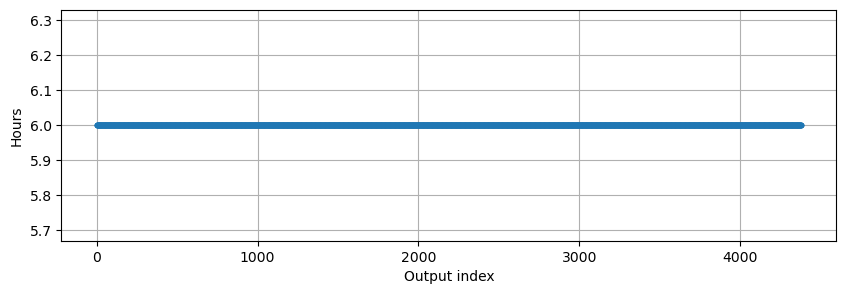

Unique time steps: [6.]


In [4]:
for ctl in Path(NEW_DIR).glob("attm102.ctl"):
    print("=" * 80)
    print(ctl.name)

    ds = open_CtlDataset(str(ctl))
    dt = np.diff(ds.time.values) / np.timedelta64(1, "h")

    plt.figure(figsize=(10,3))
    plt.plot(dt, ".-")
    plt.ylabel("Hours")
    plt.xlabel("Output index")
    plt.grid(True)
    plt.show()

    print("Unique time steps:", np.unique(dt))

In [5]:
ds

<xarray.Dataset> Size: 8GB
Dimensions:  (time: 4380, lev: 8, lat: 48, lon: 96)
Coordinates:
  * time     (time) datetime64[ns] 35kB 1989-01-01 ... 1991-12-31T18:00:00
  * lev      (lev) float64 64B 925.0 850.0 700.0 500.0 300.0 200.0 100.0 30.0
  * lat      (lat) float64 384B -87.16 -83.48 -79.78 ... 79.78 83.48 87.16
  * lon      (lon) float32 384B 0.0 3.75 7.5 11.25 ... 345.0 348.8 352.5 356.2
Data variables: (12/39)
    GH       (time, lev, lat, lon) >f4 646MB dask.array<chunksize=(1, 1, 48, 96), meta=np.ndarray>
    TEMP     (time, lev, lat, lon) >f4 646MB dask.array<chunksize=(1, 1, 48, 96), meta=np.ndarray>
    U        (time, lev, lat, lon) >f4 646MB dask.array<chunksize=(1, 1, 48, 96), meta=np.ndarray>
    V        (time, lev, lat, lon) >f4 646MB dask.array<chunksize=(1, 1, 48, 96), meta=np.ndarray>
    Q        (time, lev, lat, lon) >f4 646MB dask.array<chunksize=(1, 1, 48, 96), meta=np.ndarray>
    RH       (time, lev, lat, lon) >f4 646MB dask.array<chunksize=(1, 1, 48, 96), meta=np.ndarray>
    ...       ...
    OLR      (time, lat, lon) >f4 81MB dask.array<chunksize=(1, 48, 96), meta=np.ndarray>
    SSR      (time, lat, lon) >f4 81MB dask.array<chunksize=(1, 48, 96), meta=np.ndarray>
    SLR      (time, lat, lon) >f4 81MB dask.array<chunksize=(1, 48, 96), meta=np.ndarray>
    SHF      (time, lat, lon) >f4 81MB dask.array<chunksize=(1, 48, 96), meta=np.ndarray>
    LSHF     (time, lat, lon) >f4 81MB dask.array<chunksize=(1, 48, 96), meta=np.ndarray>
    SSHF     (time, lat, lon) >f4 81MB dask.array<chunksize=(1, 48, 96), meta=np.ndarray>
Attributes:
    comment:  geopotential height               [m]
    storage:  99
    title:    Means/variances
    undef:    9.999e+19
    pdef:     None

In [6]:
var = ds["ST"] - 273.15

var.attrs["units"] = "°C"

# lon 0..360 -> -180..180
var = var.assign_coords(
    lon=(((var.lon + 180) % 360) - 180)
).sortby("lon")

temp_cmap = LinearSegmentedColormap.from_list(
    "TemperatureBlueWhiteRed",
    [
        "#313695",  # very cold, dark blue
        "#4575b4",
        "#74add1",
        "#abd9e9",
        "#e0f3f8",
        "#ffffff",  # around 0 C
        "#fee090",
        "#fdae61",
        "#f46d43",
        "#d73027",
        "#a50026",  # very hot, dark red
    ],
    N=256
)

levels = np.arange(-50, 50, 2.5)

norm = mcolors.TwoSlopeNorm(
    vmin=levels.min(),
    vcenter=0,
    vmax=levels.max()
)

cbar_ticks = np.arange(levels.min(),levels.max(), 10)

# =========================
# 3. Widgets
# =========================

t_slider = widgets.IntSlider(
    min=0,
    max=var.sizes["time"] - 1,
    step=1,
    value=0,
    description="time"
)

# lev_slider = widgets.IntSlider(
#     min=0,
#     max=var.sizes["lev"] - 1,
#     step=1,
#     value=0,
#     description="lev"
# )

prev_btn = widgets.Button(description="← prev")
next_btn = widgets.Button(description="next →")

out = widgets.Output()


# =========================
# 4. Plot function
# =========================

#def draw(t, lev):
#    da = var.isel(time=t, lev=lev)

def draw(t):
    da = var.isel(time=t)    

    with out:
        clear_output(wait=True)

        fig = plt.figure(figsize=(13, 6.5), facecolor="white")
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.set_facecolor("white")

        da.plot.contourf(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=temp_cmap,
            levels=levels,
            norm=norm,
            extend="both",
            add_colorbar=True,
            cbar_kwargs={
                "orientation": "horizontal",
                "pad": 0.07,
                "shrink": 0.75,
                "ticks": cbar_ticks,
                "label": "Temperature [°C]"
            }
        )

        ax.coastlines(linewidth=0.7)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)

        # ax.set_title(
        #     f"TEMP, level={float(var.lev.values[lev]):g}, "
        #     f"time={str(ds.time.values[t])}"
        # )
        ax.set_title(
            f"Surface temperature,"
            f"time={str(ds.time.values[t])}"
        )

        plt.show()
        plt.close(fig)


# =========================
# 5. Buttons and callbacks
# =========================

def on_prev(_):
    t_slider.value = max(t_slider.min, t_slider.value - 1)

def on_next(_):
    t_slider.value = min(t_slider.max, t_slider.value + 1)

def on_change(change):
    #draw(t_slider.value, lev_slider.value)
    draw(t_slider.value)
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

t_slider.observe(on_change, names="value")
#lev_slider.observe(on_change, names="value")


# =========================
# 6. Display
# =========================

#display(widgets.HBox([prev_btn, next_btn, t_slider, lev_slider]))
display(widgets.HBox([prev_btn, next_btn, t_slider]))
display(out)

#draw(t_slider.value, lev_slider.value)
draw(t_slider.value)

Output()

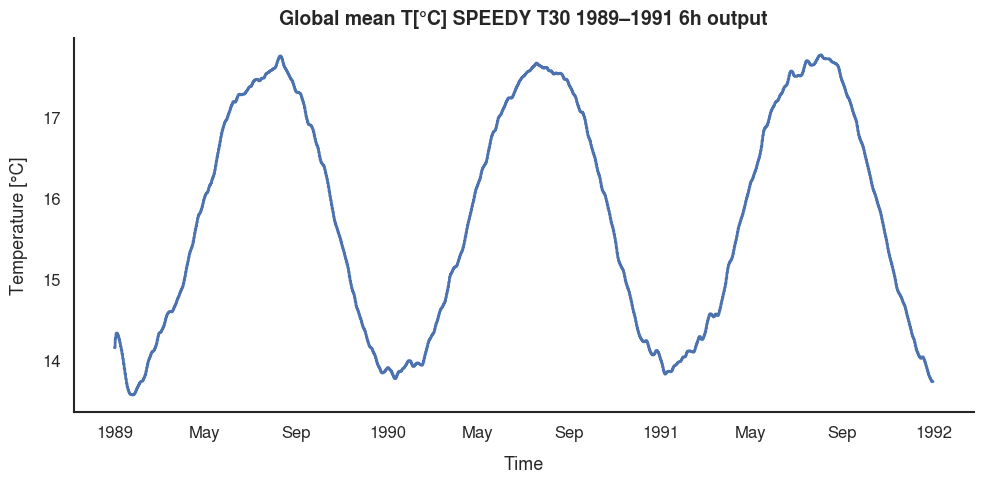

In [7]:
sns.set_theme(style="white")

plt.rcParams.update({"font.family": "Nimbus Sans"})
#lev_index = 1  # level
#var.isel(lev=lev_index).mean(dim=("lat", "lon"), skipna=True).plot()

fig, ax = plt.subplots(figsize=(10, 5))
#var.mean(dim=("lat", "lon"), skipna=True).plot(ax=ax,linewidth=2)

weights = np.cos(np.deg2rad(var.lat))

global_mean = var.weighted(weights).mean(dim=("lat", "lon"),skipna=True)

global_mean.plot(ax=ax, linewidth=2)

ax.set_title("Global mean T[°C] SPEEDY T30 1989–1991 6h output",
    fontsize=14,pad=10,fontweight="bold")

ax.set_ylabel("Temperature [°C]",fontsize=13,labelpad=10)
ax.set_xlabel("Time",fontsize=13,labelpad=10)

ax.tick_params(axis="both",labelsize=12,width=1.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

fig.tight_layout()
plt.show()

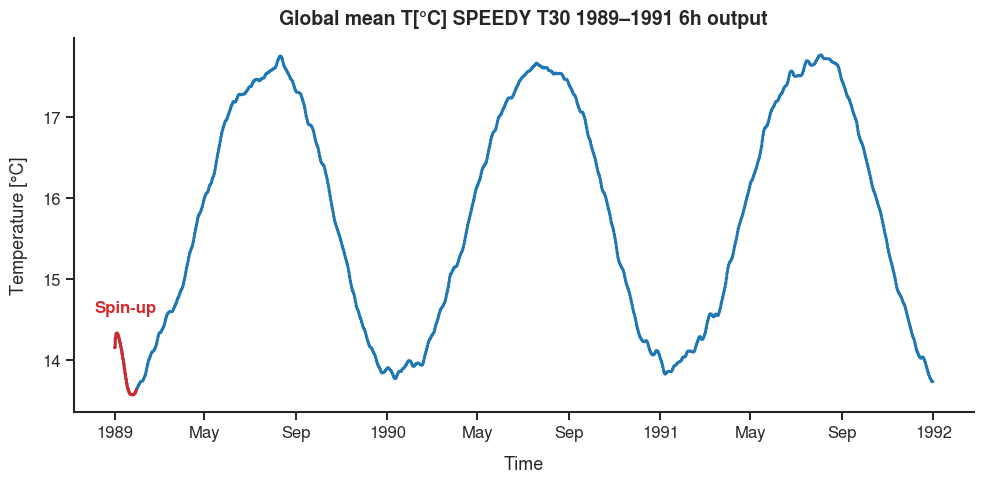

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"font.family": "Nimbus Sans"})

# Global mean temperature
weights = np.cos(np.deg2rad(var.lat))

mean_temp =  var.weighted(weights).mean(dim=("lat", "lon"),skipna=True)
spinup_end = pd.Timestamp("1989-01-31")

time = pd.to_datetime(mean_temp.time.values)
spinup = time < spinup_end

fig, ax = plt.subplots(figsize=(10, 5))

mean_temp.plot(ax=ax,linewidth=2,color="tab:blue")

ax.plot(time[spinup],mean_temp.values[spinup],color="tab:red",linewidth=2)

spinup_middle = time[spinup][len(time[spinup]) // 2] # spin-up label

ax.text(spinup_middle,0.3,"Spin-up",transform=ax.get_xaxis_transform(),color="tab:red",
    fontsize=12,fontweight="bold",ha="center",va="top")

ax.set_title("Global mean T[°C] SPEEDY T30 1989–1991 6h output",fontsize=14,
    pad=10,fontweight="bold")

ax.set_ylabel("Temperature [°C]",fontsize=13,labelpad=10)

ax.set_xlabel("Time",fontsize=13,labelpad=10)

ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")

ax.tick_params(axis="both",which="major",direction="out",length=6,width=1.2,labelsize=12,
    bottom=True,left=True,top=False,right=False,color="black")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

fig.tight_layout()

fig.savefig("../figures/sp_T30_globT_1989_1991_6h.png",dpi=150,bbox_inches="tight")

plt.show()